In [1]:
# imports
from dataset_utils import *
from matplotlib import pyplot as plt

In [2]:
def eval_dataset(dataset_loader):
    """
    prints some metrics about the provided dataset
    :param dataset_loader: the dataset to analyze
    """
    tweet_counts = {}
    user_counts = {}

    for i, sample in enumerate(dataset_loader):
        label = sample.label
        tweet_count = len(sample.tweet_data)

        if not label in list(tweet_counts.keys()):
            tweet_counts[label] = []
            user_counts[label] = 0
        tweet_counts.get(label).append(tweet_count)
        user_counts[label] = 1 + user_counts.get(label)
        print(f"\rIteration: {i}", end="")
    print("")
    print("----------")
    print("Amount of labeled users: ", user_counts)
    for key in list(tweet_counts.keys()):
        plt.title("Tweet Counts Distribution: " + key)
        plt.hist(tweet_counts.get(label), bins=100)
        plt.show()

def preview_one_sample(dataset_loader, wanted_label):
    """
    previews one sample from the dataset for the specified label
    :param dataset_loader: the dataset to take a sample from
    :param wanted_label: the wanted sample type
    """
    sample = None
    for i, pick in enumerate(dataset_loader):
        if pick.label == wanted_label:
            sample = pick
            break

    print("----------")
    print("label: ", sample.label)
    print("user meta data: ", sample.user_data)
    print("----------")
    for i,tweet in enumerate(sample.tweet_data):
        print("tweet: ", tweet.text)
    print("----------")

Iteration: 8886
----------
Amount of labeled users:  {'human': 2563, 'fake_follower': 2348, 'social_spam1': 73, 'social_spam2': 2764, 'social_spam3': 356, 'traditional_spam1': 783}


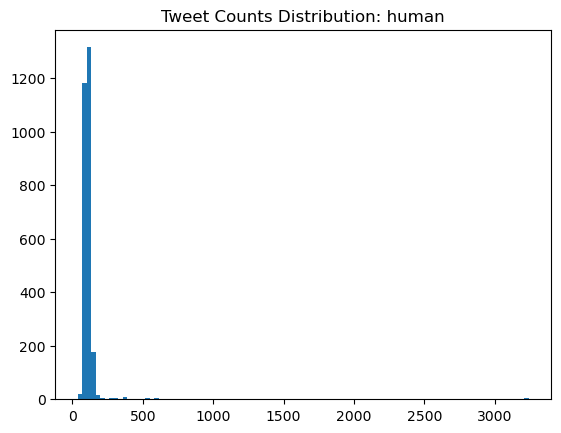

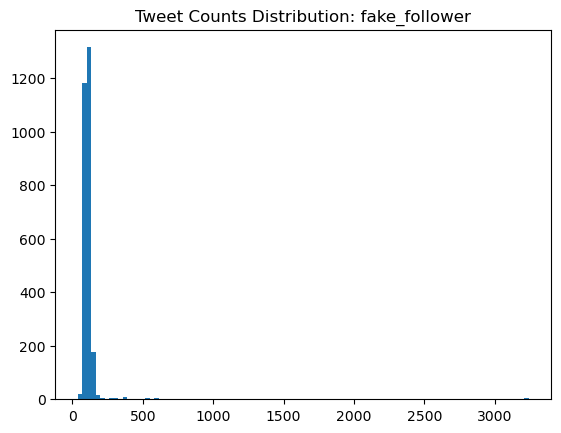

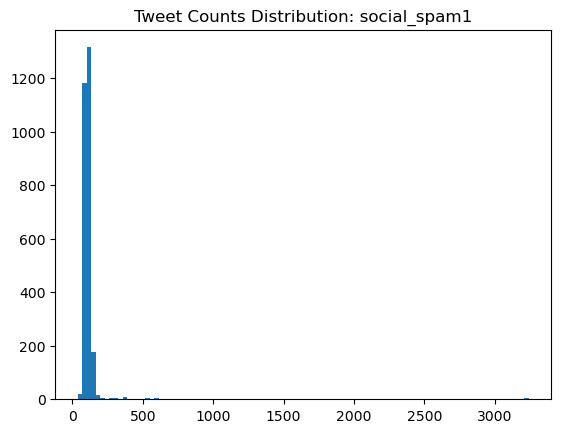

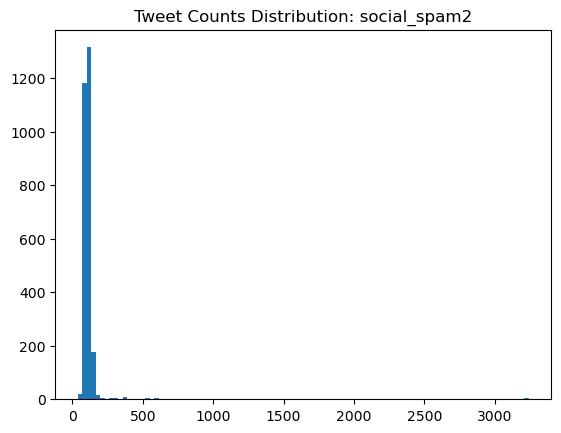

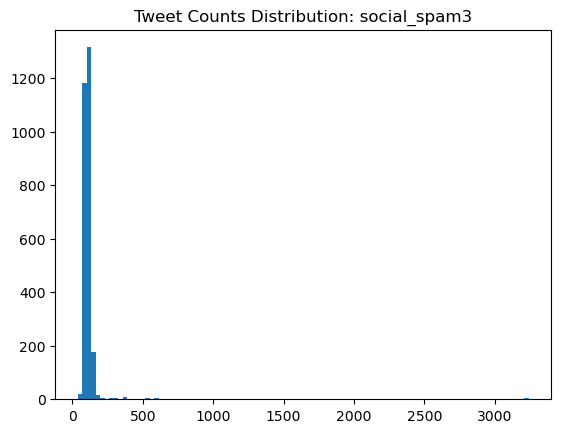

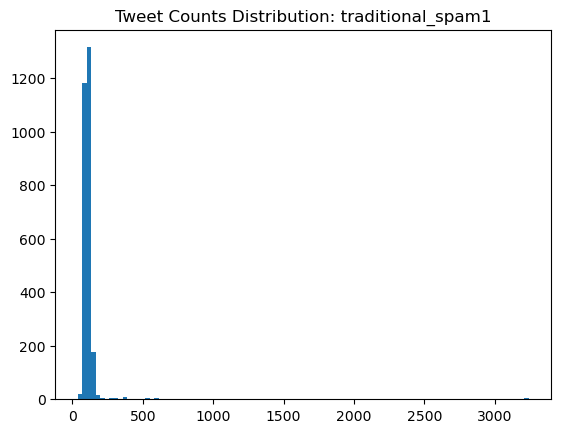

----------
label:  human
user meta data:  UserData(id='u191839658', name='pocahontas farida', screen_name='wadespeters', statuses_count=202968, followers_count=2248, friends_count=981, favourites_count=60304, listed_count=101, lang='en', verified=0)
----------
tweet:  rt @steviebuckys: do i look aesthetic yet http://t.co/pcdwayv2bv
tweet:  @steviebuckys marry me
tweet:  rt @mattrnurdock: scarlett johansson deserves better http://t.co/uygjao27vm
tweet:  my favorite cutie patootiesâºï¸ http://t.co/63625hebza
tweet:  rt @ljpphotos: http://t.co/1oseleytzm
tweet:  rt @tweet_palestine: ethiopians in #israel serve in the army yesterday they protested against israeli police brutality israeli racism http:â¦
tweet:  rt @pimpdaddysyd: im gonna be singing its gonna be may all day http://t.co/0gizfmcvla
tweet:  rt @time: let justin timberlake remind you that âitâs gonna be mayâ http://t.co/zayarsmukf
tweet:  happy friday :)
tweet:  rt @ayeshalucarelli: one god, allah. #quran http://t.co/qo

In [3]:
# Dataset: Cresci 17
dataset_mode = "train"
user_dataset = Cresci17(Cresci17SetTypes.GENUINE_USER, dataset_mode, root="./datasets", custom_label="human")
fake_dataset = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, dataset_mode, root="./datasets", custom_label="fake_follower")
social1_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, dataset_mode, root="./datasets", custom_label="social_spam1")
social2_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_2, dataset_mode, root="./datasets", custom_label="social_spam2")
social3_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_3, dataset_mode, root="./datasets", custom_label="social_spam3")
traditional1_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_1, dataset_mode, root="./datasets", custom_label="traditional_spam1")
combo_dataset = InterleavedIterableDataset([user_dataset, fake_dataset, social1_dataset, social2_dataset, social3_dataset, traditional1_dataset], "RoundRobin")

eval_dataset(combo_dataset)
preview_one_sample(combo_dataset, "human")

In [ ]:
# Dataset: Cresci 18
dataset = Cresci18("train", root="./datasets", use_only_labelled=True, label_mapping=["bot","human","unlabelled"])
eval_dataset(dataset)
preview_one_sample(dataset, "human")

In [ ]:
# Dataset: Caverlee 11
dataset = Caverlee11("train", root="./datasets", label_mapping=["bot","human"])
eval_dataset(dataset)
preview_one_sample(dataset, "human")

--> Loading labels...
--> Loaded 99923 labels for split 'test'
--> Loading users (This will take a while via ijson)...
    Processed 50000 users...
--> Successfully cached 50000 users in memory.
--> Initializing disk cache database...
--> Streaming tweets safely via ijson from: tweet_0.json
--> Streaming tweets safely via ijson from: tweet_1.json
--> Streaming tweets safely via ijson from: tweet_2.json
--> Streaming tweets safely via ijson from: tweet_3.json
--> Streaming tweets safely via ijson from: tweet_4.json
--> Streaming tweets safely via ijson from: tweet_5.json
--> Streaming tweets safely via ijson from: tweet_6.json
--> Streaming tweets safely via ijson from: tweet_7.json
--> Streaming tweets safely via ijson from: tweet_8.json
--> Packaging and yielding complete samples for 99923 users...
Iteration: 99922--> Temporary disk cache cleaned up successfully.

----------
Amount of labeled users:  {'human': 85945, 'bot': 13978}


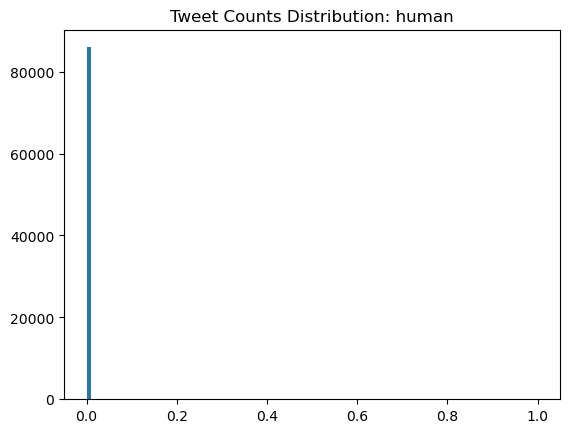

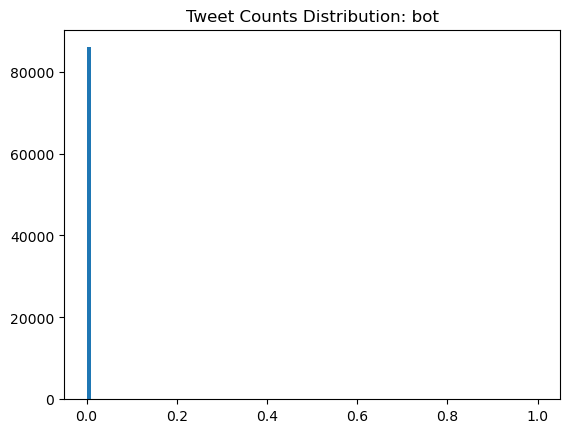

--> Loading labels...
--> Loaded 99923 labels for split 'test'
--> Loading users (This will take a while via ijson)...
    Processed 50000 users...
--> Successfully cached 50000 users in memory.
--> Initializing disk cache database...
--> Streaming tweets safely via ijson from: tweet_0.json
--> Streaming tweets safely via ijson from: tweet_1.json
--> Streaming tweets safely via ijson from: tweet_2.json
--> Streaming tweets safely via ijson from: tweet_3.json
--> Streaming tweets safely via ijson from: tweet_4.json
--> Streaming tweets safely via ijson from: tweet_5.json
--> Streaming tweets safely via ijson from: tweet_6.json
--> Streaming tweets safely via ijson from: tweet_7.json
--> Streaming tweets safely via ijson from: tweet_8.json
--> Packaging and yielding complete samples for 99923 users...
----------
label:  human
user meta data:  UserData(id='u457554412', name='samsmith', screen_name=None, statuses_count=0, followers_count=0, friends_count=0, favourites_count=0, listed_count

In [3]:
# Dataset: Twibot 20
dataset = Twibot22("train", root="./datasets", label_mapping=["bot", "human"])
eval_dataset(dataset)
preview_one_sample(dataset, "human")

In [ ]:
# Dataset: Twibot 22
dataset = Twibot22("train", root="./datasets", label_mapping=["bot","human"])
eval_dataset(dataset)
preview_one_sample(dataset, "human")